In [9]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# --- 1. Configuration ---
DATA_DIR = r"C:\Users\tarun\Desktop\IRMAS-TrainingData" 
TEST_DIR = r"C:\Users\tarun\Desktop\IRMAS-TestingData-Part1\Part1"
BATCH_SIZE = 32
IMG_SHAPE = (128, 130, 1)
PRED_THRESHOLD = 0.20

instrument_list = ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
label_map = {inst: i for i, inst in enumerate(instrument_list)}
NUM_CLASSES = len(instrument_list)

instrument_map = {
    'cel': 'Celesta',         'cla': 'Clarinet',        'flu': 'Flute',
    'gac': 'Acoustic Guitar', 'gel': 'Electric Guitar', 'org': 'Organ',
    'pia': 'Piano',           'sax': 'Saxophone',       'tru': 'Trumpet',
    'vio': 'Violin',          'voi': 'Human Voice'
}

In [2]:
# --- 2. File Discovery ---
file_paths = []
labels = []

for root, dirs, files in os.walk(DATA_DIR):
    folder_name = os.path.basename(root)
    if folder_name in label_map:
        idx = label_map[folder_name]
        for file in files:
            if file.endswith(".wav"):
                file_paths.append(os.path.join(root, file))
                # Change: labels are float32 vectors of shape (11,), each position represents one instrument (0.0 or 1.0)
                label_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
                label_vec[idx] = 1.0
                labels.append(label_vec)

labels = np.array(labels, dtype=np.float32)  # Change: shape (N, 11) instead of (N,)
print(f"Found {len(file_paths)} training files")

# Split training data to train/val
# Change: stratify uses argmax because labels are now vectors
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42,
    stratify=np.argmax(labels, axis=1)
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

Found 6705 training files
Train: 5364 | Val: 1341


In [3]:
# Converts raw .wav files into normalized Mel-spectrogram images for the CNN to "see"
def process_audio(file_path, label):
    def _parse_audio(fp):
        # Convert the TensorFlow tensor back into a standard Python string (file path)
        fp = fp.numpy().decode('utf-8')
        
        # Load audio file: 22050 samples per second, restricted to exactly 3.0 seconds
        audio, _ = librosa.load(fp, sr=22050, duration=3.0)
        
        # If audio is shorter than 3s (66,150 samples), add zeros to the end
        if len(audio) < 66150:
            audio = np.pad(audio, (0, 66150 - len(audio)))
        
        # Convert raw sound waves into a Mel-spectrogram (frequency over time)
        # n_mels=128 creates 128 vertical "frequency bins"
        spec = librosa.feature.melspectrogram(y=audio, sr=22050, n_mels=128)
        
        # Convert amplitude units to Decibels (log scale) so details aren't lost
        spec_db = librosa.power_to_db(spec, ref=np.max)
        
        # Normalize: shift -80..0 range to 0..1 for faster training (v2)
        spec_db = (spec_db + 80.0) / 80.0
        spec_db = np.clip(spec_db, 0, 1)
        
        # Add a gray channel dimension (128, 130) -> (128, 130, 1) to mimic a grayscale image
        return spec_db[..., np.newaxis].astype(np.float32)

    # Wrap the Python function so TensorFlow can run it as part of the "Graph"
    [image,] = tf.py_function(_parse_audio, [file_path], [tf.float32])
    image.set_shape(IMG_SHAPE)
    return image, label


# Builds an optimized, shuffled, and batched data pipeline to feed the GPU efficiently
def make_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(len(paths))
    ds = ds.map(process_audio, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels)
val_ds   = make_dataset(val_paths,   val_labels)

In [4]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=IMG_SHAPE),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    # Change: sigmoid instead of softmax
    tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    # Change: binary_crossentropy
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        # Change: Add AUC (Area Under the Curve) measures how well the model ranks instruments (regardless of threshold)
        # 0.5 = random guessing, 1.0 = perfect
        tf.keras.metrics.AUC(multi_label=True, name='auc')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 59520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,618,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,639,307 (29.14 MB)

 Trainable params: 7,639,115 (29.14 MB)

 Non-trainable params: 192 (768.00 B)

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 135s 778ms/step - accuracy: 0.1401 - auc: 0.5626 - loss: 0.5023 - val_accuracy: 0.1074 - val_auc: 0.5692 - val_loss: 1.1030
Epoch 2/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 135s 806ms/step - accuracy: 0.2052 - auc: 0.6408 - loss: 0.3660 - val_accuracy: 0.0887 - val_auc: 0.5991 - val_loss: 0.7672
Epoch 3/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 132s 783ms/step - accuracy: 0.2446 - auc: 0.6755 - loss: 0.3435 - val_accuracy: 0.2983 - val_auc: 0.7051 - val_loss: 0.3168
Epoch 4/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 152s 844ms/step - accuracy: 0.2691 - auc: 0.7032 - loss: 0.3269 - val_accuracy: 0.3154 - val_auc: 0.7574 - val_loss: 0.2755
Epoch 5/5
168/168 ━━━━━━━━━━━━━━━━━━━━ 121s 721ms/step - accuracy: 0.3186 - auc: 0.7310 - loss: 0.3082 - val_accuracy: 0.3915 - val_auc: 0.7775 - val_loss: 0.2597


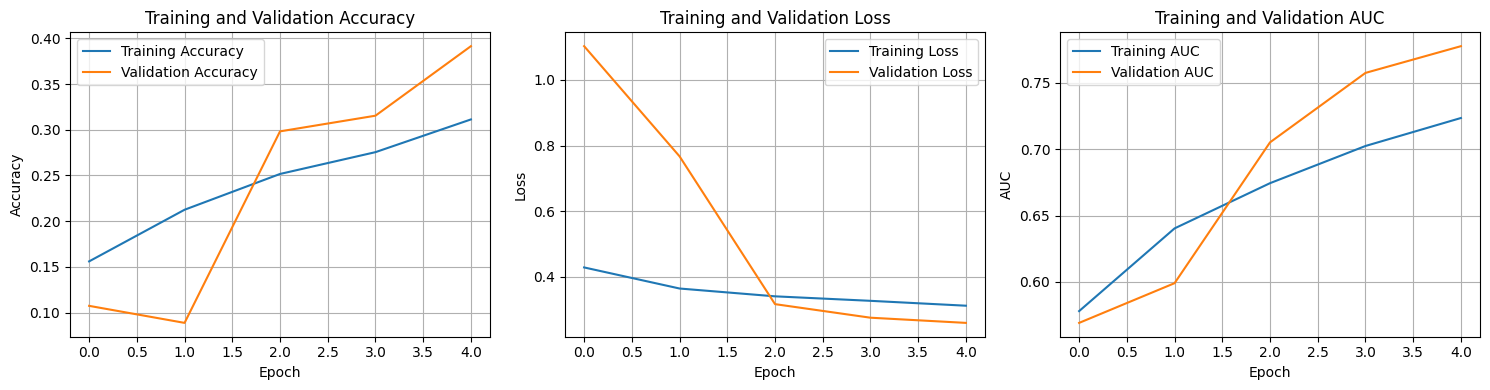

Best epoch: 5
Validation Accuracy: 0.3915
Validation Loss:     0.2597
Validation AUC:      0.7775
------------------------------
Training Accuracy:   0.3113
Training Loss:       0.3120


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))  # Change: fit new AUC plot

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch');  plt.ylabel('Accuracy');  plt.legend();  plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch');  plt.ylabel('Loss');  plt.legend();  plt.grid(True)

# Change: added AUC plot = tracks how well the model ranks instruments overall (unaffected by the choice of threshold)
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'],     label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epoch');  plt.ylabel('AUC');  plt.legend();  plt.grid(True)

plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history['val_loss'])
print(f"Best epoch: {best_epoch + 1}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"Validation Loss:     {history.history['val_loss'][best_epoch]:.4f}")
print(f"Validation AUC:      {history.history['val_auc'][best_epoch]:.4f}")  # Change: added AUC
print("-" * 30)
print(f"Training Accuracy:   {history.history['accuracy'][best_epoch]:.4f}")
print(f"Training Loss:       {history.history['loss'][best_epoch]:.4f}")

In [10]:
## THRESHOLD IS THE CONFIDENCE BAR WHICH DECIDES IF THERE IS AN X INSTRUMENT IN THE SAMPLE.
## WE HAVE 11 INSTRUMENTS SO RANDOM GUESSING WOULD BE AROUND 0.09.
## SO IF WE HAVE THRESHOLD OF 0.20 IT NEEDS TO HAVE ATLEAST 0.20 PROBABILITY TO BE FLAGGED
## THAT THE INSTRUMENT IS IN THE SAMPLE.

# Change: returns a probability vector (11,) instead of a single float for one instrument -> all instruments are evaluated in one pass per file
def predict_on_test_file(file_path, model):
    audio, sr = librosa.load(file_path, sr=22050)  # sample rate, 22,050 * 3 = 66,150 samples per chunk
    chunk_size = 66150  # 3 seconds
    chunk_probs = []

    for i in range(0, len(audio) - chunk_size, chunk_size):
        chunk = audio[i : i + chunk_size]
        spec    = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=128)
        spec_db = librosa.power_to_db(spec, ref=np.max)  # v2
        spec_db = (spec_db + 80.0) / 80.0               # v2
        spec_db = np.clip(spec_db, 0, 1)                 # v2
        inp  = spec_db[np.newaxis, ..., np.newaxis]
        pred = model.predict(inp, verbose=0)
        chunk_probs.append(pred[0])  # CHANGED: shape (11,) instead of a single float

    # Return the highest confidence found across all 3s windows per instrument
    # If the instrument appears once, the whole file is flagged as a match (depending on the threshold)
    # Change: np.max over axis=0 to get per-instrument max across chunks
    return np.max(chunk_probs, axis=0) if chunk_probs else np.zeros(NUM_CLASSES)


test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.wav')])

# Change: y_true and y_pred_probs are now 2D arrays (num_files, 11) instead of 1D
y_true       = []
y_pred_probs = []

for f in test_files:
    file_path = os.path.join(TEST_DIR, f)
    txt_path  = os.path.splitext(file_path)[0] + '.txt'

    # Change: label is now a vector — all instruments mentioned in the .txt are flagged
    label_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as t:
            labels_in_file = [item.strip() for item in t.read().split()]
            for code in labels_in_file:
                if code in label_map:
                    label_vec[label_map[code]] = 1.0

    y_true.append(label_vec)
    y_pred_probs.append(predict_on_test_file(file_path, model))

y_true        = np.array(y_true)
y_pred_probs  = np.array(y_pred_probs)
y_pred_binary = (y_pred_probs > PRED_THRESHOLD).astype(int)

print(f"Evaluated {len(test_files)} test files")

Evaluated 807 test files


In [11]:
# RECALL    = "Of all the X instruments in the test set, how many did the model actually find?"
# PRECISION = "When the model says it's a X instrument, how often is it actually a X instrument?"
# F1 SCORE  = harmonic mean of precision and recall "The balance of the two"

# Change: one report to cover all 11 instruments
print(f"Multilabel Classification Report (threshold={PRED_THRESHOLD}):\n")
print(classification_report(
    y_true,
    y_pred_binary,
    target_names=[instrument_map[k] for k in instrument_list]
))

Multilabel Classification Report (threshold=0.2):

                 precision    recall  f1-score   support

        Celesta       0.06      0.27      0.09        26
       Clarinet       0.01      0.12      0.01         8
          Flute       0.08      0.43      0.13        28
Acoustic Guitar       0.49      0.48      0.49       145
Electric Guitar       0.44      0.61      0.51       241
          Organ       0.17      0.59      0.26        91
          Piano       0.51      0.31      0.38       367
      Saxophone       0.41      0.71      0.52       167
        Trumpet       0.27      0.18      0.22        79
         Violin       0.14      0.80      0.24        51
    Human Voice       0.31      0.96      0.46       229

      micro avg       0.29      0.56      0.38      1432
      macro avg       0.26      0.50      0.30      1432
   weighted avg       0.39      0.56      0.41      1432
    samples avg       0.36      0.59      0.40      1432


C:\kNNClassifier\.venv\Neural-Networks-Project\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Results with 5 epochs and threshold 0.20

This is the report after only 5 epochs of training. It can probably be expected that the results improve with a run with more epochs.

**Precision** — "When the model says instrument X is present, how often is it right?"
**Recall** — "Of all samples that actually contain instrument X, how many did the model find?"
**F1-score** — Single score that balances both precision and recall, punishing cases where one is much lower than the other
**Support** — How many test samples actually contained that instrument


In [14]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_true, y_pred_probs, average='macro')
print(f"Test AUC: {auc_score:.4f}")

Test AUC: 0.6986


The AUC is fairly good with only 5 epochs

In [12]:
model.save("irmas_instrument_classifier_v3_multilabel.keras")
print("Model saved.")

Model saved.
